# Project 1: Counting words in college subreddits

Due 9/16. Reminder that you are allowed to use any amount of AI assistance or outside resources with citation

## Part 1: word counting and bag of words

In [40]:
#install spacy in the current conda environment
!pip install spacy


In [41]:
#download a small language model to help with cleaning tasks
!python -m spacy download en_core_web_sm



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 41.7 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [42]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [43]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [44]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [45]:
#import required libraries
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import spacy
language_model = spacy.load("en_core_web_sm")
import matplotlib.pyplot as plt

import numpy as np

### Problem 1 and example: common words in the Michigan subreddit

In [46]:
#read the data from a csv file in the folder
mich=pd.read_csv("umich.csv")

In [47]:
#jupyter will print a pretty representation of most python objects if you just put the name
#we can see that the full text of each reddit comment is provided in the "text" column
mich

,Unnamed: 0,date,post_votes,text,user,com_votes
0,0,2024-09-04 15:33:20,2,"Zingermans has a nice reuben, pretty pricey bu...",Suspicious-Bad703,2
1,1,2024-09-04 15:33:20,2,I really love Tomokun!,webstbre000,2
2,2,2024-09-04 15:33:20,2,The Seoul is pretty good I especially like the...,iaxlmao,1
3,3,2024-09-04 15:33:20,2,A lot of it depends on what type of food and w...,I-696,1
4,4,2024-09-04 14:32:17,1,You can book completely enclosed private study...,sneep_,2
...,...,...,...,...,...,...
8334,8334,2024-07-02 12:35:36,9,It isn’t a student org,Vibes_And_Smiles,1
8335,8335,2024-07-02 11:07:10,0,Life \nMatter \nLife's matter,tctu,8
8336,8336,2024-07-02 11:07:10,0,google,SUPERazkari,4
8337,8337,2024-07-02 11:07:10,0,That’s a hard question to answer for a set of ...,Own-Resident-3837,-1


In [48]:
#this is a function that does some light cleaning, by removing newline characters, converting to lowercase, and removing punctuation

def clean(text):
    #remove newline and space characters
    text = ' '.join(text.split())
    #convert the text to lowercase
    text = text.lower()
    #remove punctuation
    text = ''.join([char for char in text if char.isalpha() or char.isspace()])
    return text

In [49]:
#pandas allows us to quickly apply this cleaning function to all rows in a column
mich['cleaned_text'] = mich['text'].apply(clean)

In [50]:
#we can see the first comment after cleaning vs before
mich["cleaned_text"][0]

'zingermans has a nice reuben pretty pricey but the sammies are pretty big'

In [51]:
mich["text"][0]

'Zingermans has a nice reuben, pretty pricey but the sammies are pretty big'

In [52]:
#create a bag of words representation with count vectorizer
vectorizer = CountVectorizer()
bag_of_words = vectorizer.fit_transform(mich['cleaned_text'])

In [53]:
#this is a sparse matrix, which is a more efficient way to store a matrix with many zeros
#the matrix has 8339 rows (one for each comment) and 15289 columns (one for each unique word in the dataset)
bag_of_words

<8339x15289 sparse matrix of type '<class 'numpy.int64'>'
	with 221217 stored elements in Compressed Sparse Row format>

In [54]:
#create a dataframe from the sparse matrix
#this is a more human-readable way to view the data
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
bow_df

,aa,aadl,aapd,aata,ab,abab,abandon,abandoned,abbreviation,abbreviations,...,zoned,zones,zoning,zoo,zoom,zoomer,zoomers,zuckerberg,𝓲𝓷𝓼𝓮𝓬𝓾𝓻𝓮,𝘢𝘩𝘦𝘮
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8334,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8335,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8336,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8337,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
#dataframes have a convenient method for summing the values in each column
#this will give us the number of times each word appears in the dataset
word_counts = bow_df.sum()
#we can sort the values to see the most common words
word_counts = word_counts.sort_values(ascending=False)

#notice that the top words are not very informative, as they are common words that appear in many contexts
#and bottom words include a lot of typos and other noise
word_counts

the            11306
to              8480
and             6921
you             6256
of              5028
               ...  
journals           1
journeywhen        1
jpg                1
js                 1
𝘢𝘩𝘦𝘮               1
Length: 15289, dtype: int64

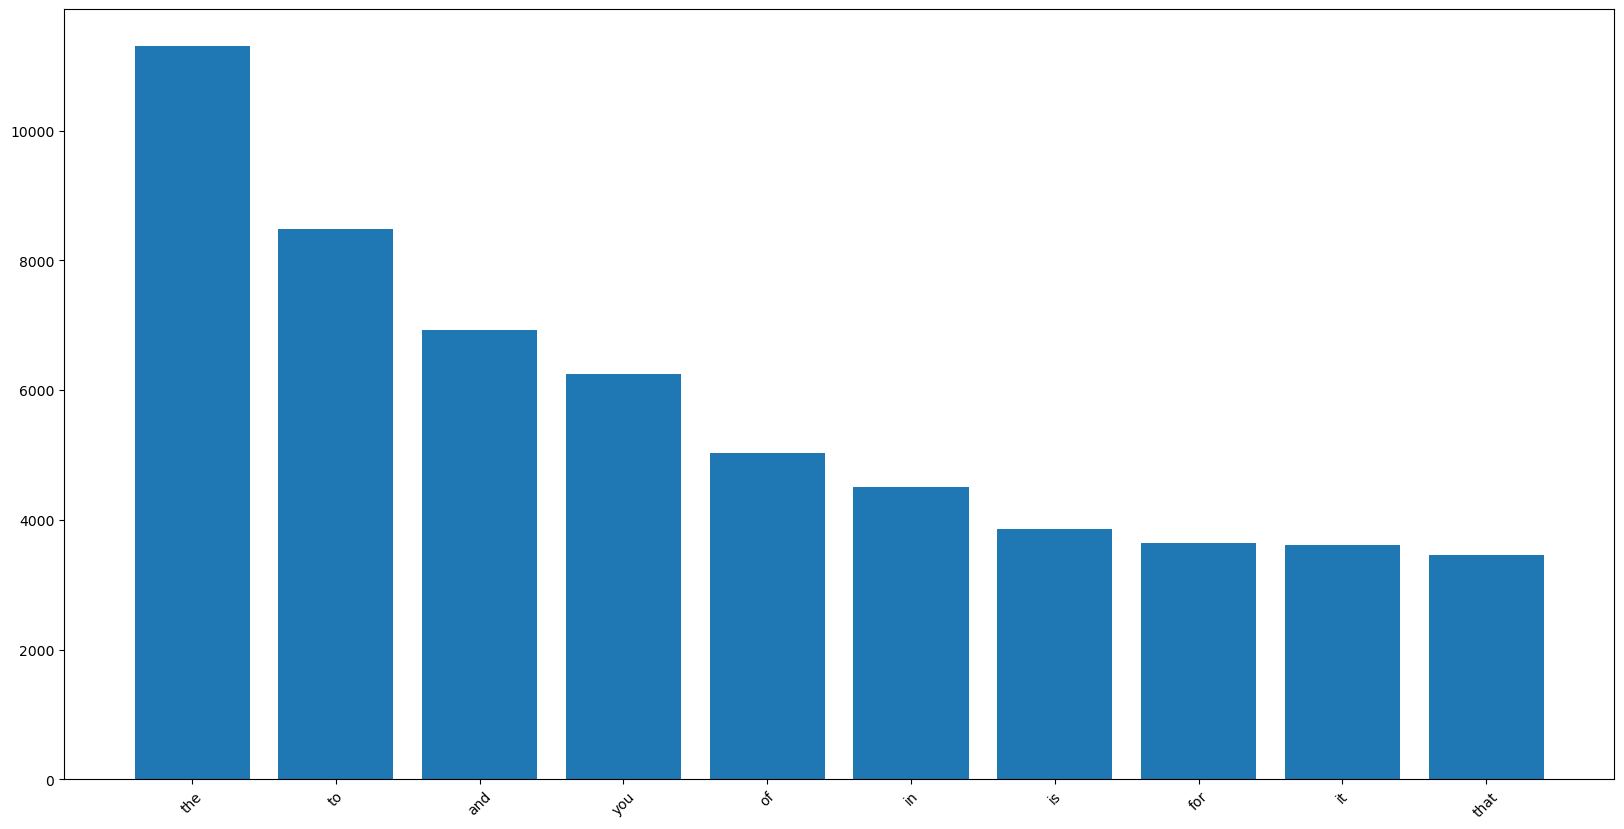

In [56]:
#we can plot the most common words
#we will only plot the top 10 words for readability
word_counts = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(word_counts.index, word_counts.values)
plt.xticks(rotation=45)
plt.show()

#### Question 1: what do you notice about the words in this plot? Is this useful for studying the community?

Answer here: 

#### Lemmatization and stopword removal

In [57]:
#lemmatization function from the openclassrooms reading
def lemmatize(text):

   doc = language_model(text)

   tokens = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]

   return ' '.join(tokens)

In [58]:
#we can further process the text by removing stopwords and lemmatizing
mich['lemmatized_text'] = mich['cleaned_text'].apply(lemmatize)

In [59]:
#count vectorizer also has parameters min_df and max_df that can be used to filter out words that are too rare or too common
#min_df=3 means that a word must appear in at least 3 documents to be included, this will remove typos and rare words
#max_df=0.3 means that a word must appear in at most 30% of documents to be included, this will remove corpus-specific stopwords

#we are also able to include n-grams in the count vectorizer
#n-grams are sequences of n words that appear together in the text
#the n-gram_range parameter specifies the minimum and maximum n-gram size to include (so in this case, we are including both unigrams and bigrams)

vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
bag_of_words = vectorizer.fit_transform(mich['lemmatized_text'])

In [60]:
#we can see that we filtered out 11000 common words and typos
bag_of_words

<8339x8637 sparse matrix of type '<class 'numpy.int64'>'
	with 126833 stored elements in Compressed Sparse Row format>

In [61]:
#we can repeat the previous code to create a dataframe and count the words
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())
word_counts = bow_df.sum()
word_counts = word_counts.sort_values(ascending=False)
word_counts

not               2862
student           1183
like              1183
people            1124
class              988
                  ... 
sell minnesota       3
cred                 3
credential           3
sell oregon          3
pay dollar           3
Length: 8637, dtype: int64

In [106]:
#we can convert this to a percentage instead of an absolute count by dividing by the total number of words
word_counts = word_counts / word_counts.sum()

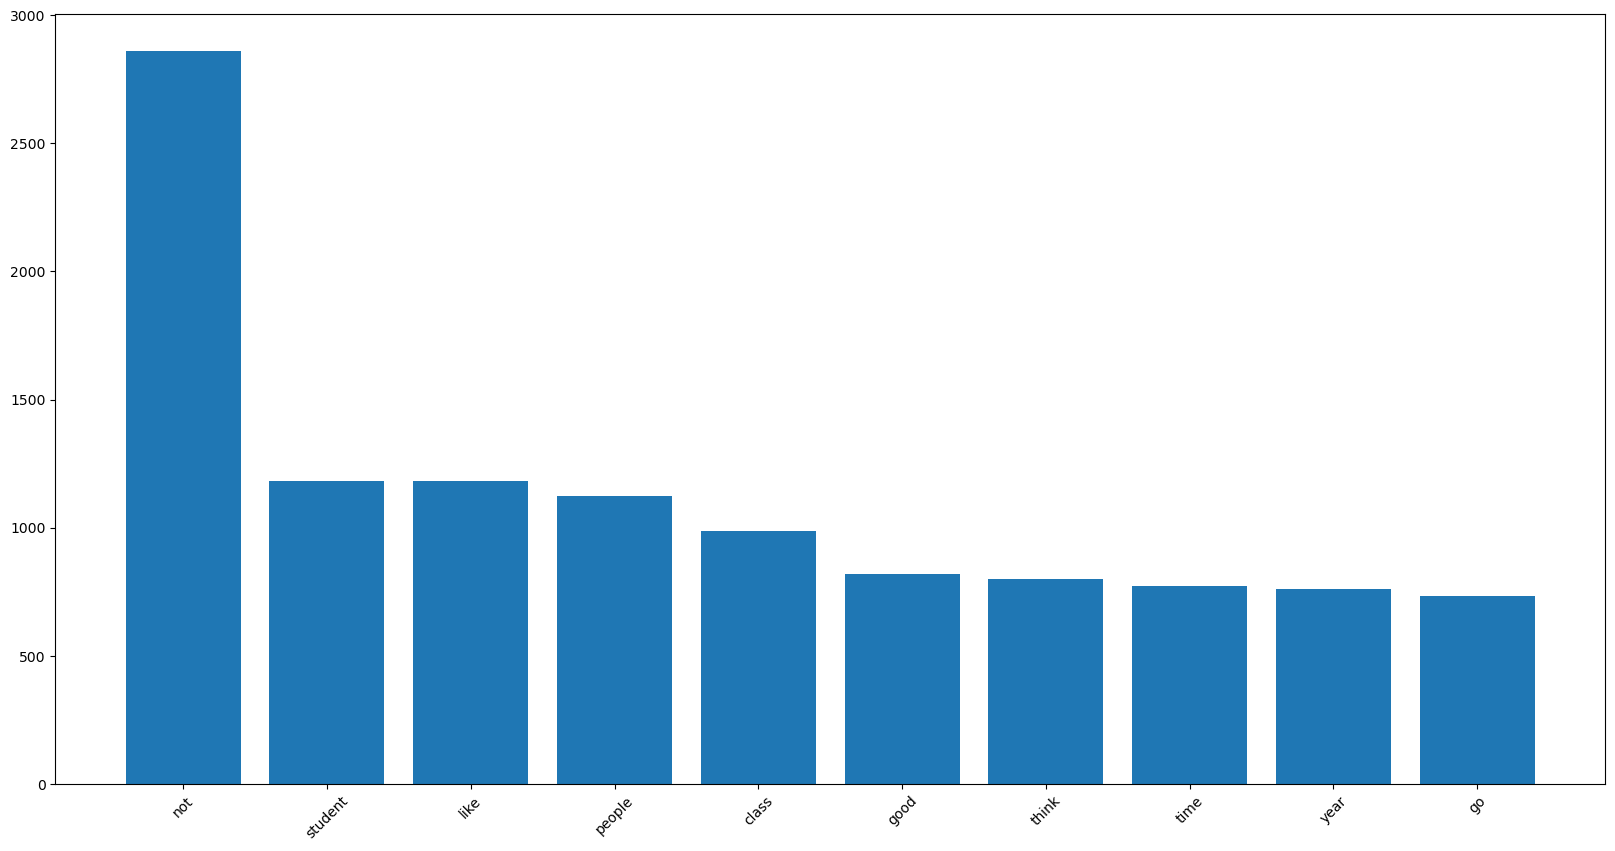

In [62]:
#we can plot the most common words
#we will only plot the top 10 words for readability
plot_list = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

In [63]:
#pandas allows us to access specific words in the series using the index
word_counts["student loan"]

6

In [64]:
#we can also use a list of words to compare and plot specific words
plot_list=word_counts[["history", "business", "computer science", "cs", "computer"]]
plot_list

history              51
business             87
computer science      5
cs                  178
computer             38
dtype: int64

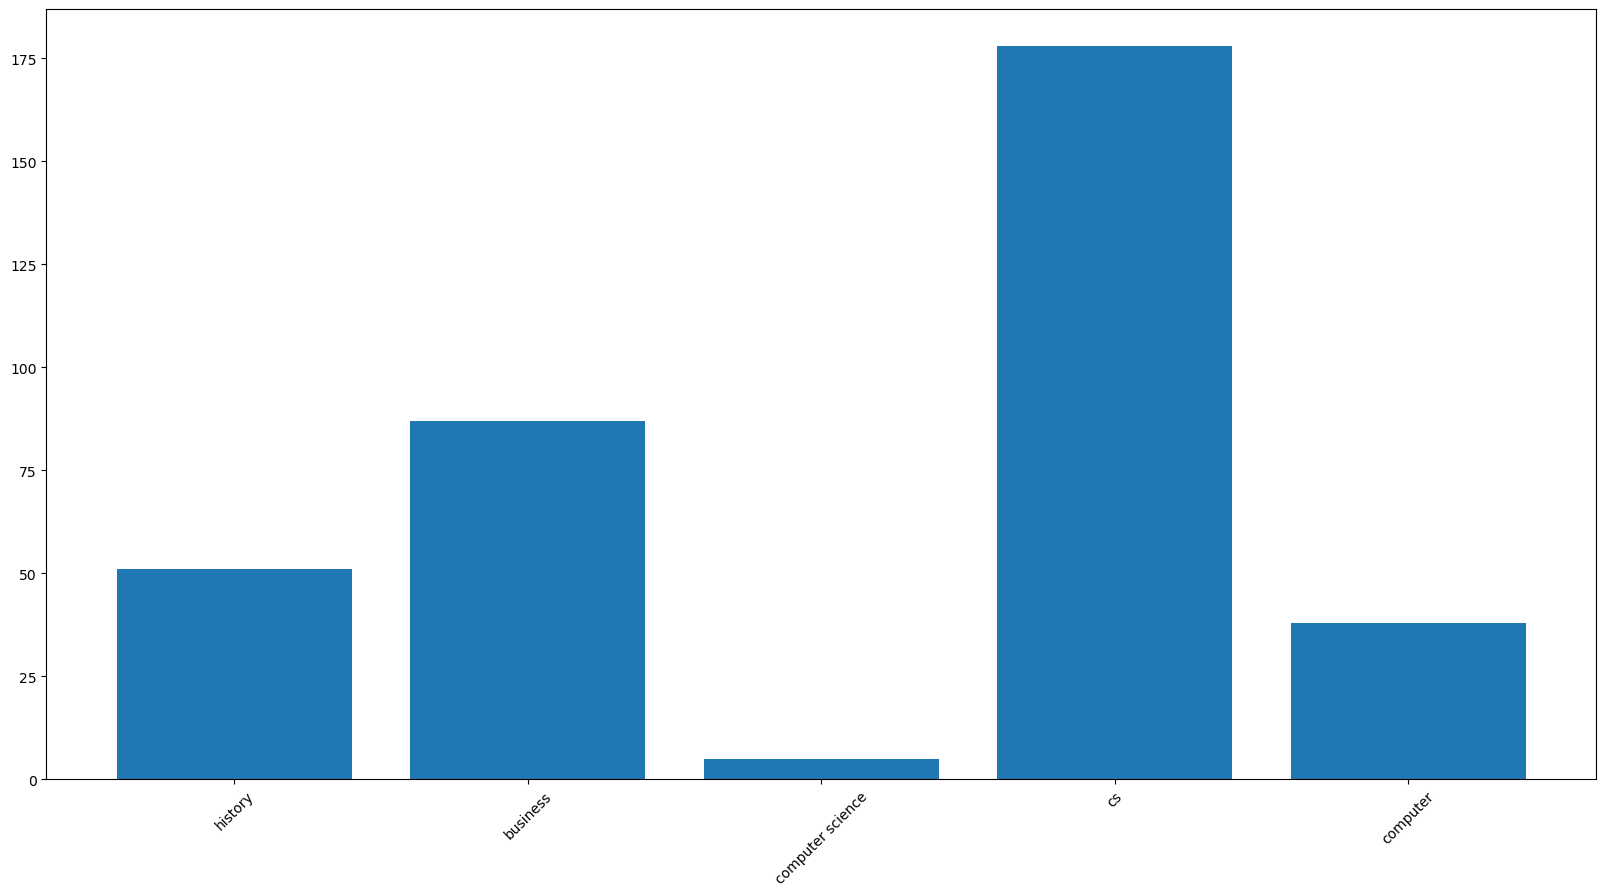

In [65]:

plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

#### Question 2:

In [66]:
#TODO: pick 5 words that you find interesting or are curious about, and plot a bar plot of their frequency in this dataset 

In [67]:
#we can also use a list of words to compare and plot specific words
plot_list=word_counts[["school", "student", "teacher", "class", "grade"]]
plot_list



school      552
student    1183
teacher      12
class       988
grade        95
dtype: int64

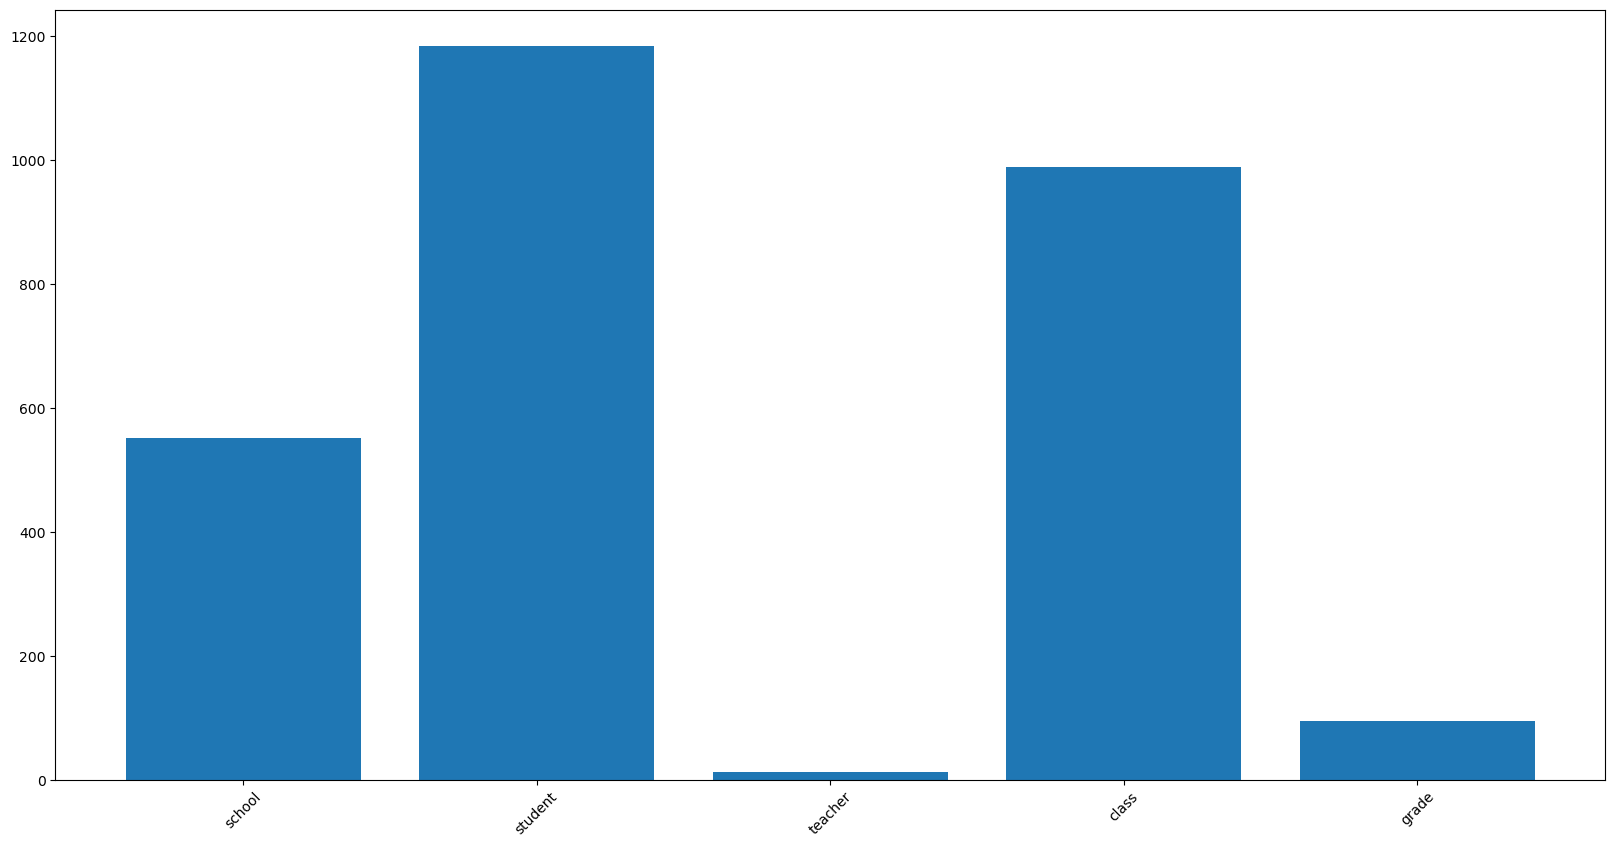

In [68]:
plt.figure(figsize=(20,10))
plt.bar(plot_list.index, plot_list.values)
plt.xticks(rotation=45)
plt.show()

### Problem 2: repeat this process with the Illinois subreddit data (in this directory as "uiuc.csv"). You should not have to change too much in the previous code besides the dataframe path and name. Your notebook should include the two bar graphs including and excluding stopwords. Use the same 5 words and compare their relative frequency between the two subreddits. Discuss any interesting differences you notice in a short markdown cell. 

In [69]:
uiuc=pd.read_csv("uiuc.csv")


In [70]:
uiuc['cleaned']=uiuc['text'].apply(clean)
uiuc['lemmatized']=uiuc['cleaned'].apply(lemmatize)

In [71]:
vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
bag_of_words = vectorizer.fit_transform(uiuc['lemmatized'])

In [72]:
bag_of_words

<4725x3891 sparse matrix of type '<class 'numpy.int64'>'
	with 49429 stored elements in Compressed Sparse Row format>

In [73]:
bow_df = pd.DataFrame(bag_of_words.toarray(), columns=vectorizer.get_feature_names_out())

#count the word frequency in illinois subreddit
words_counts_uiuc = bow_df.sum()
words_counts_uiuc = words_counts_uiuc.sort_values(ascending=False)

In [74]:
word_counts = words_counts_uiuc / words_counts_uiuc.sum()

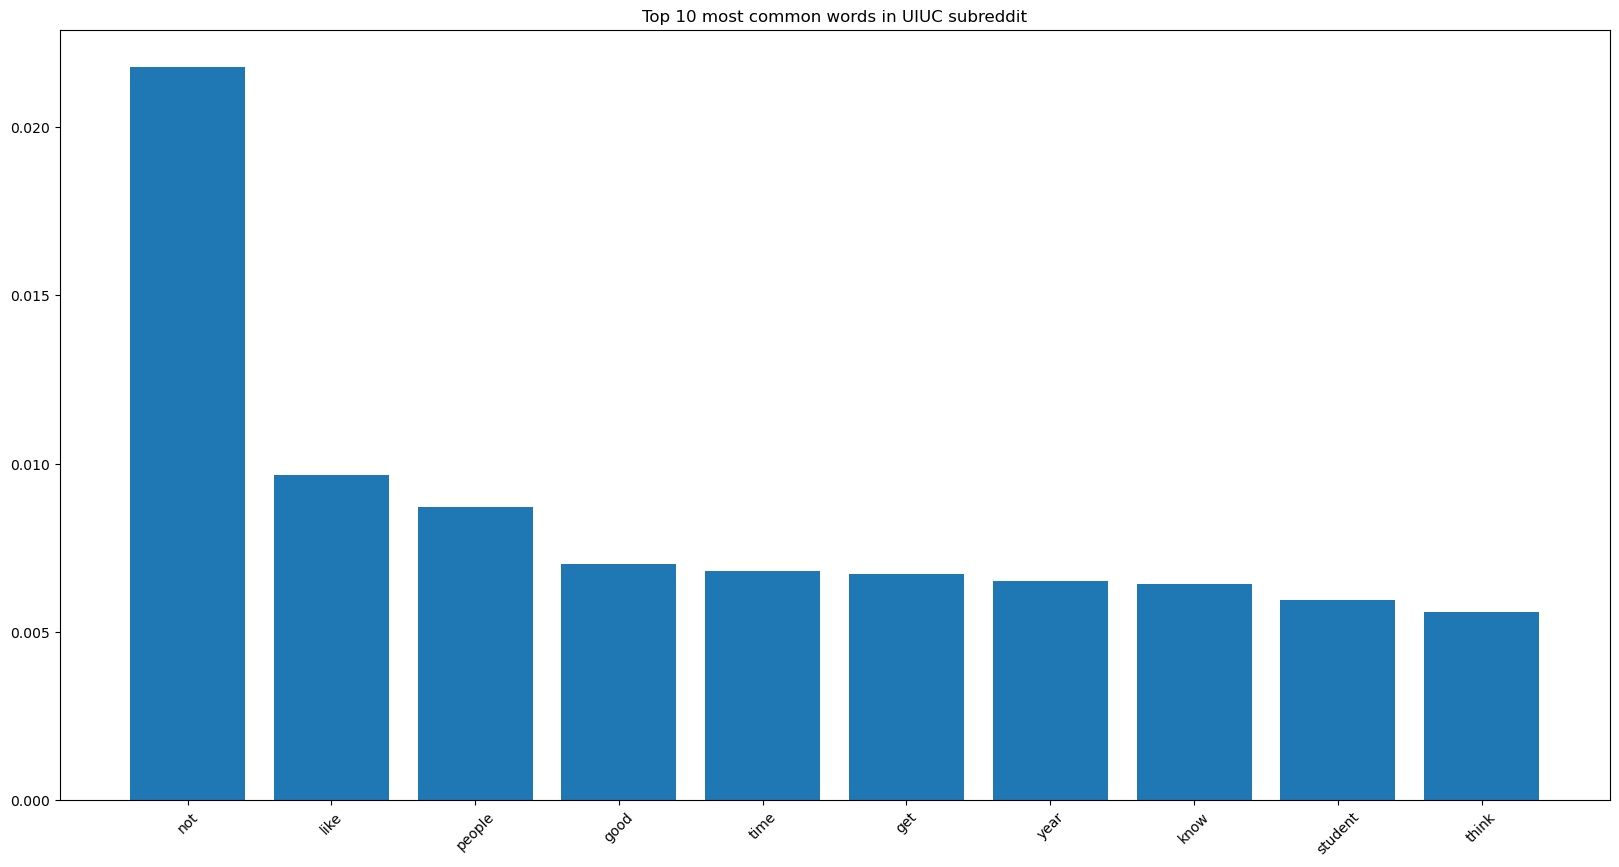

In [75]:
top_10_words_uiuc = word_counts.head(10)
plt.figure(figsize=(20,10))
plt.bar(top_10_words_uiuc.index, top_10_words_uiuc.values) 
plt.xticks(rotation=45) 
plt.title("Top 10 most common words in UIUC subreddit")
plt.show()

In [76]:
word_counts["people"]

0.008703991893163477

In [81]:
plot_list_uiuc=word_counts[["school", "student", "teacher", "class", "grade"]]
plot_list_uiuc


school     0.001864
student    0.005935
teacher    0.000109
class      0.005483
grade      0.000579
dtype: float64

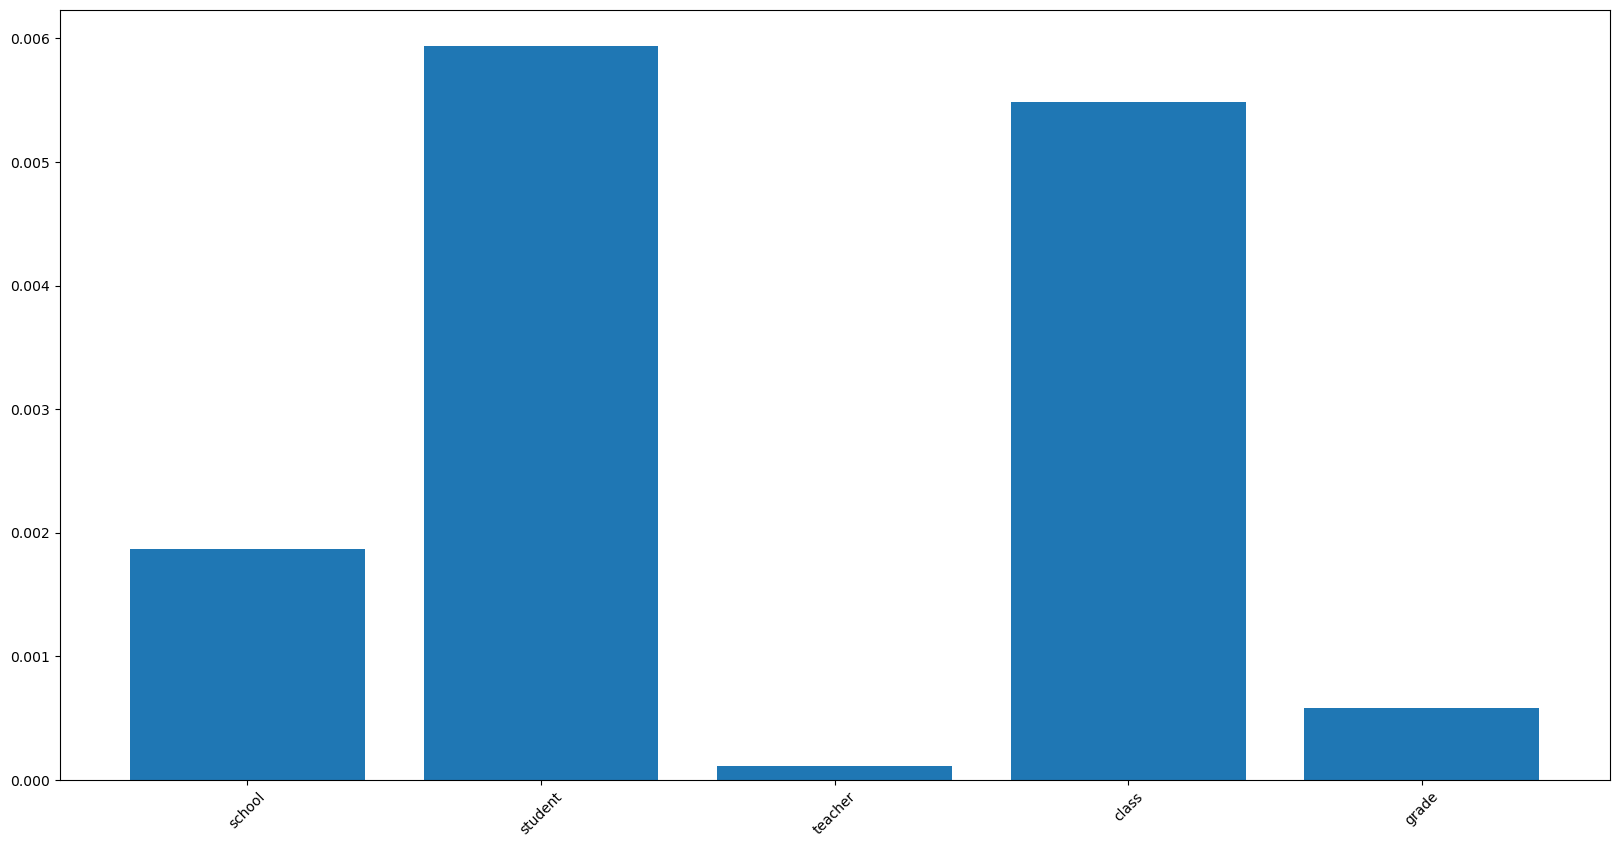

In [82]:
plt.figure(figsize=(20,10))
plt.bar(plot_list_uiuc.index, plot_list_uiuc.values)    
plt.xticks(rotation=45)
plt.show()

The graphs are almost identical.

### Problem 3: using the provided combined dataframe, train a logistic regression model using the sklearn Logistic Regression implementation. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html. Create a bag of words table from the combined data, and use that along with the "label" column to train the classifier. Please try this out and be prepared with issues or questions next Monday. We will be discussing in class

In [103]:
uiuc=pd.read_csv("uiuc.csv")
mich=pd.read_csv("umich.csv")

#sample so we have even number of samples from each dataset
mich=mich.sample(n=4725)

#assign labels based on origin subreddit of comment
uiuc['label']=1
mich['label']=0

#you will be working with the data csv for the rest of the question
data=pd.concat([uiuc,mich])

In [104]:
#clean and lemmatize the data csv

In [105]:
data['cleaned_text'] = data['text'].apply(clean)
data['lemmatized_text'] = data['cleaned_text'].apply(lemmatize)
data

,Unnamed: 0,date,post_votes,text,user,com_votes,label,cleaned_text,lemmatized_text
0,0,2024-09-04 14:43:40,2,Have the same professor! And in lecture he did...,zhen3441,2,1,have the same professor and in lecture he did ...,professor lecture go to learn stuff ourself re...
1,1,2024-09-04 14:43:40,2,Do you find it helpful to still go to the lect...,Kai2747,1,1,do you find it helpful to still go to the lect...,find helpful lecture slide embed mistake make ...
2,2,2024-09-04 12:52:08,3,Have you tried emailing University Housing to ...,TurboBKTastic,2,1,have you tried emailing university housing to ...,try email university housing request access
3,3,2024-09-04 12:52:08,3,Purchasing Illini Cash should get you added to...,HoosierCAB,2,1,purchasing illini cash should get you added to...,purchase illini cash add nonresident meal plan...
4,4,2024-09-04 12:52:08,3,"Just did, thanks for the suggestion! It hadn't...",Sector-Both,1,1,just did thanks for the suggestion it hadnt oc...,thank suggestion not occur
...,...,...,...,...,...,...,...,...,...
1476,1476,2024-08-28 16:13:43,793,Not a Wolverine… can absolutely confirm that i...,paniemilia,1,0,not a wolverine can absolutely confirm that it...,wolverine absolutely confirm great lake southe...
6627,6627,2024-07-16 21:38:32,6,There are not many jobs in cybersecurity you c...,_iQlusion,14,0,there are not many jobs in cybersecurity you c...,job cybersecurity cybersecurity problem entr...
4282,4282,2024-08-11 17:04:59,242,I agree that their comms about this stuff coul...,louisebelcherxo,2,0,i agree that their comms about this stuff coul...,agree comms stuff definitely well public idk t...
2852,2852,2024-08-24 02:01:51,142,It’s only been a week. This stuff takes time....,A2MacGeek,11,0,its only been a week this stuff takes time jus...,week stuff take time go event interest overly ...


In [ ]:
#create a bag of words representation with count vectorizer

In [106]:
data_vectorizer = CountVectorizer(min_df=3, max_df=0.3, ngram_range=(1,2))
data_bag_of_words = data_vectorizer.fit_transform(data['lemmatized_text'])
data_bag_of_words

<9450x8383 sparse matrix of type '<class 'numpy.int64'>'
	with 124236 stored elements in Compressed Sparse Row format>

In [107]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
#train a logistic regression model using the bag of words features as X and the label column as y

In [88]:
logistic_model = LogisticRegression()
logistic_model.fit(data_bag_of_words, data['label'])

LogisticRegression()

In [ ]:
#report the accuracy of the model

In [89]:
logistic_model.score(data_bag_of_words, data['label'])

0.8987301587301587

#### Part 2: hold out part of the dataset using sklearn train_test_split (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). Pass in your previously generated bag of words as X and the label column as y. Use only the X_train and y_train for training and hold out the X_test and y_test to score the model on unseen data.

In [ ]:
# what is the accuracy of the model? Is it better or worse than previous?Why do you think it has changed? 

In [90]:
X_train, X_test, y_train, y_test = train_test_split(data_bag_of_words, data['label'], test_size=0.2, random_state=103)

In [91]:
logistic_model.fit(X_train, y_train)

LogisticRegression()

In [92]:
logistic_model.score(X_test, y_test)

0.7222222222222222

The model's accuracy is much lower when it's not trained on the whole dataset. This happens because it has to predict things it hasn't seen before. Models usually do worse on test data when it's kept separate from the training data, compared to when they're trained on the entire dataset and then asked to make predictions.

#### Part 3: Examine the top features of your model using the following code

In [ ]:
#get the coefficients of the model and plot the top 10 most positive and top 10 most negative coefficients
#what do you notice about these words? Are they surprising or expected?


In [93]:
bow_df = pd.DataFrame(data_bag_of_words.toarray(), columns=data_vectorizer.get_feature_names_out())

In [96]:
coefficients = pd.DataFrame({'feature': bow_df.columns, 'coefficient': logistic_model.coef_[0]})
coefficients = coefficients.sort_values('coefficient', ascending=False)
top_10_positive = coefficients.head(10)
top_10_negative = coefficients.tail(10)

In [97]:
top_10_negative

,feature,coefficient
8097,winter,-1.568623
7194,texas,-1.587932
7709,uofm,-1.776585
7882,waitlist,-1.833259
4101,lsa,-1.885875
1666,diag,-2.010558
7616,umich,-2.048552
7615,um,-2.164023
2469,fresno,-2.253558
4339,michigan,-2.977356


In [98]:
top_10_positive

,feature,coefficient
7608,uiuc,2.215469
2856,grainger,2.051809
7723,urbana,2.010231
3292,illinois,1.947241
3289,illini,1.866752
6120,rsos,1.850228
1504,danville,1.690603
2891,green,1.597295
7468,tow,1.571267
916,champaign,1.470979


In [ ]:
#examine these words and see if they make sense. Do they differentiate UIUC from another university?

Yes, it’s clear when looking at the most positive and negative words that this dataset shows UIUC in a better light than UMich. Most of the positive words are related to UIUC, while the negative ones are about Michigan.


### Problem 4: Train a 10 topic topic model from the UIUC subreddit data using Gensim LDA. (https://radimrehurek.com/gensim/auto_examples/tutorials/run_lda.html) If you get here before Wednesday 9/11, don't rush to finish, but feel free to continue ahead. We will go through this in class. Print out the top words in each topic, and read through the words for each topic to decide the theme of the topic: remember this is subjective and there are no right or wrong answers. Print out a few comments with high frequencies of each topic and analyze if your topic labels were representative. 

In [128]:
!pip install gensim

In [129]:
from gensim import corpora
from gensim.models import LdaModel
from gensim.matutils import Sparse2Corpus

In [130]:
uiuc["cleaned_text"] = uiuc['text'].apply(clean)

In [131]:
ldax = vectorizer.fit_transform(uiuc['cleaned_text'])

In [132]:
corpus = Sparse2Corpus(ldax, documents_columns=False)

In [133]:
id2word = dict((v, k) for k, v in vectorizer.vocabulary_.items())

In [116]:

corpus

In [134]:
Lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=20)
Lda_model.show_topics()

[(10,
  '0.014*"if" + 0.011*"of" + 0.009*"be" + 0.009*"is" + 0.008*"still" + 0.007*"your" + 0.007*"are" + 0.007*"it" + 0.007*"can" + 0.006*"we"'),
 (15,
  '0.013*"be" + 0.011*"it" + 0.011*"dont" + 0.010*"is" + 0.009*"like" + 0.008*"think" + 0.007*"that" + 0.007*"do" + 0.007*"this" + 0.007*"on"'),
 (7,
  '0.017*"it" + 0.015*"in" + 0.011*"of" + 0.010*"this" + 0.009*"is" + 0.008*"for" + 0.007*"have" + 0.007*"be" + 0.007*"think" + 0.007*"was"'),
 (6,
  '0.020*"it" + 0.014*"on" + 0.011*"for" + 0.011*"is" + 0.009*"out" + 0.008*"thanks" + 0.008*"give it" + 0.008*"got" + 0.007*"of" + 0.007*"but"'),
 (2,
  '0.022*"is" + 0.014*"of" + 0.012*"campus" + 0.011*"are" + 0.011*"on" + 0.010*"that" + 0.010*"there" + 0.009*"in" + 0.008*"for" + 0.007*"have"'),
 (11,
  '0.016*"is" + 0.016*"of" + 0.012*"that" + 0.009*"are" + 0.009*"on" + 0.009*"your" + 0.008*"this" + 0.008*"im" + 0.008*"for" + 0.007*"in"'),
 (17,
  '0.013*"it" + 0.012*"they" + 0.011*"that" + 0.010*"of" + 0.010*"for" + 0.010*"but" + 0.009*"in

In [135]:
import textwrap

pd.set_option('display.max_colwidth', None)
toprint=uiuc['cleaned_text'][30]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)

pmd


In [136]:
Lda_model.get_document_topics(corpus[30])

[(0, 0.05),
 (1, 0.05),
 (2, 0.05),
 (3, 0.05),
 (4, 0.05),
 (5, 0.05),
 (6, 0.05),
 (7, 0.05),
 (8, 0.05),
 (9, 0.05),
 (10, 0.05),
 (11, 0.05),
 (12, 0.05),
 (13, 0.05),
 (14, 0.05),
 (15, 0.05),
 (16, 0.05),
 (17, 0.05),
 (18, 0.05),
 (19, 0.05)]

In [137]:
models=Lda_model.get_document_topics(corpus, minimum_probability=0.0)

In [138]:
rows = []
for i in range(len(models)):
    row = []
    for m in models[i]:
        row.append(m[1])
    rows.append(row)

topic_df = pd.DataFrame(rows)

In [139]:
topic_df.sort_values(3, ascending=False)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
1961,0.000747,0.000747,0.000747,0.985802,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747,0.000747
1526,0.001140,0.001140,0.001140,0.978337,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140,0.001140
790,0.001222,0.001222,0.001222,0.976785,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222,0.001222
1889,0.001251,0.001251,0.001251,0.976228,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251,0.001251
1517,0.014784,0.000695,0.000695,0.972702,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695,0.000695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1093,0.000182,0.000182,0.000182,0.000182,0.000182,0.000182,0.010748,0.010801,0.055912,0.000182,0.000182,0.000182,0.028310,0.000182,0.008590,0.000182,0.000182,0.617737,0.265537,0.000182
1543,0.000173,0.000173,0.155362,0.000173,0.004618,0.000173,0.021912,0.054630,0.239765,0.000173,0.000173,0.007568,0.149794,0.000173,0.036668,0.043297,0.106966,0.117786,0.047325,0.013099
241,0.000158,0.032669,0.000158,0.000158,0.000158,0.000158,0.018543,0.000158,0.043633,0.000158,0.000158,0.000158,0.092382,0.009272,0.000158,0.000788,0.000158,0.640691,0.000403,0.159886
2599,0.000154,0.021274,0.128788,0.000154,0.000154,0.000154,0.016441,0.000154,0.130967,0.004128,0.000154,0.012493,0.181554,0.000154,0.021054,0.000154,0.015868,0.187497,0.252804,0.025896


In [144]:
import textwrap

pd.set_option('display.max_colwidth', None)
toprint=uiuc['cleaned_text'][60]
wrapped_string = textwrap.fill(toprint, width=80)
print(wrapped_string)



they havent been enforcing it much post covid but ymmv and nowadays its a hassle
to book the room  borrow and return the keys you could also do talbot the lounge
can get a little loud but you definitely wont have an issue where you feel bad
talking and theres mel too also probably doable places in everitt itself if you
look around depending on the time
